In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras as k
import tensorflow_addons as tfa
from tensorflow.keras import layers, models
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import code.machine_learning.encode.binding_2D_matrix_encoder as b2dme



# parameters
file_path = 'AGO2_CLASH_Hejret2023.tsv'
num_of_epochs = 10  # number of epochs - one epoch is one iteation of the entire dataset
alphabet = {"AT": 1., "TA": 1., "GC": 1., "CG": 1.}
input_shape = (50, 20, 1)  # shape of the input image

2024-10-24 20:19:42.765321: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-24 20:19:42.830391: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 20:19:43.298701: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 20:19:43.301598: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-24 20:19:44.124723: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [2]:
# defining a custom Keras layer which inturn implements a residual block
@register_keras_serializable()
class ResBlock(layers.Layer):
    """
    Defines a Residual block based on the original ResNet paper.
    The block either maintains the input dimensions or downsamples based on the specified parameters.
    """

    def __init__(self, downsample=False, filters=16, kernel_size=3):
        """
        Initializes the residual block with optional downsampling.
        
        Parameters:
        - downsample: Boolean, whether to downsample the input (using stride of 2)
        - filters: Number of filters for the Conv2D layers
        - kernel_size: Size of the convolution kernel
        """
        # calling the parent class constructor
        super(ResBlock, self).__init__()

        # parameters for the residual block
        self.downsample = downsample
        self.filters = filters
        self.kernel_size = kernel_size

        # initialize first convolution layer, with stride 1 or 2 depending on downsampling
        self.conv1 = layers.Conv2D(kernel_size=self.kernel_size,
                                   strides=(1 if not self.downsample else 2),
                                   filters=self.filters,
                                   padding="same")
        self.activation1 = layers.ReLU()  # activation function after first convolution
        self.batch_norm1 = layers.BatchNormalization()  # batch normalization after first convolution
        
        # initialize second convolution layer with stride 1 (no downsampling here)
        self.conv2 = layers.Conv2D(kernel_size=self.kernel_size,
                                   strides=1,
                                   filters=self.filters,
                                   padding="same")

        # third convolution if downsampling is needed to match input dimensions
        if self.downsample:
          self.conv3 = layers.Conv2D(kernel_size=1,
                                     strides=2,
                                     filters=self.filters,
                                     padding="same")

        self.activation2 = layers.ReLU()  # activation after second convolution
        self.batch_norm2 = layers.BatchNormalization()  # batch normalization after second convolution

    def call(self, inputs):
        """
        Forward pass for the residual block. Applies the convolutions, activation, and adds the skip connection.

        Parameters:
        - inputs: Input tensor

        Returns:
        - Tensor after applying the residual block transformation
        """
        # first convolution, activation, and batch normalization
        x = self.conv1(inputs)
        x = self.activation1(x)
        x = self.batch_norm1(x)
        
        # second convolution (no downsampling here)
        x = self.conv2(x)

        # adjust input dimensions if downsampling
        if self.downsample:
            inputs = self.conv3(inputs)

        # add the input (skip connection) to the output of the convolutions
        x = layers.Add()([inputs, x])

        # final activation and batch normalization
        x = self.activation2(x)
        x = self.batch_norm2(x)

        return x

    def get_config(self):
        """
        Returns the configuration of the residual block (required for saving and loading the model).
        """
        return {'filters': self.filters, 'downsample': self.downsample, 'kernel_size': self.kernel_size}

In [3]:
# define the ResNet model
def build_resnet(input_shape):
    """
    Builds a simple ResNet model using custom residual blocks.
    """
    inputs = layers.Input(shape=input_shape)

    # initial Conv Layer
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same')(inputs)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    # add ResBlocks
    x = ResBlock(filters=64, downsample=False)(x)
    x = ResBlock(filters=64, downsample=False)(x)

    # flatten and add dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(2, activation='softmax')(x)  # binary classification (0 or 1)

    # build model
    model = models.Model(inputs, x)
    
    # compile the model
    model.compile(optimizer=Adam(learning_rate=0.1), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # output model summary
    model.summary()
    
    return model

In [9]:
# load the dataset
print("----- <Loading Dataset> -----")
df = pd.read_csv(file_path, sep='\t')
print("----- <Dataset loaded successfully> -----\n")

# print the dataset shape and first few rows
print(f"Dataset shape: {df.shape}")
print(f"First few rows of the dataset:\n{df.head()}\n")

# split into training and validation/testing sets
training_data, validation_data = train_test_split(df, test_size=0.2, random_state=42)
# print the size of the training and validation sets
print(f"Size of training set: {len(training_data)}")
print(f"Size of validation set: {len(validation_data)}\n")

# encode the data using your binding_2D_matrix_encoder's binding_encoding function
def encode_dataset(data):
    # use the function from the binding_2D_matrix_encoder module
    return b2dme.binding_encoding(data, alphabet)

# encode the training data and validation data
print("----- <Encoding> -----")
encoded_training_data, training_labels = encode_dataset(training_data)
encoded_validation_data, validation_labels = encode_dataset(validation_data)
# print completion message example of encoded data
print("----- <Encoding Completed> -----\n")
# print(f"Encoded training data shape: {encoded_training_data.shape}")
# print(f"Encoded validation data shape: {encoded_validation_data.shape}\n")
# print(f"First encoded training example:\n{encoded_training_data[0]}")
# print(f"First training label: {training_labels[0]}\n")

# build the ResNet model
input_shape = encoded_training_data.shape[1:]  # assuming the encoded data is 4D (samples, height, width, channels)
print("----- <Building Model> -----")
model = build_resnet(input_shape)
print("----- <Model Built> -----\n")

----- <Loading Dataset> -----
----- <Dataset loaded successfully> -----

Dataset shape: (42460, 3)
First few rows of the dataset:
             noncodingRNA                                               gene  \
0  TGAGGTAGTAGGTTGTGTGGTT  ACTTTTCTTGACTTGCCTGTTTTGGCCATTAGCTGCCTTAAACGTT...   
1  AAAAGCTGGGTTGAGAGGGCGA  CGAACTGACACTGAGCCACAACCCAAACAACCCAGCTCTCCCTAAG...   
2  TCCGAGCCTGGGTCTCCCTCTT  CGTGCGTGGCAAGCTCTCCCGGCTCGGCTCGCTCGGCCTCCCTTAC...   
3  TAGCAGCACATAATGGTTTGTG  GCACATGCCACAGCTCCTGTGAATATTGCCGGCTCCAGAACCGCCG...   
4  CAAAGAATTCTCCTTTTGGGCT  GTCTGGTCTTGAACTCTTGGGCTCAAAGAATTCTCCTGCTTCAGCC...   

   label  
0      1  
1      1  
2      1  
3      1  
4      1  

Size of training set: 33968
Size of validation set: 8492

----- <Encoding> -----
----- <Encoding Completed> -----

----- <Building Model> -----
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        

In [10]:
# train the model
print("----- <Training Model> -----")
history = model.fit(encoded_training_data, training_labels, epochs=10, validation_data=(encoded_validation_data, validation_labels))
print("----- <Model Trained> -----\n")

----- <Training Model> -----
Epoch 1/10
1062/1062 [==============================] - 224s 211ms/step - loss: 0.2757 - accuracy: 0.9186 - val_loss: 0.3019 - val_accuracy: 0.9098
Epoch 2/10
1062/1062 [==============================] - 224s 210ms/step - loss: 0.1869 - accuracy: 0.9354 - val_loss: 0.2457 - val_accuracy: 0.9185
Epoch 3/10
1062/1062 [==============================] - 230s 216ms/step - loss: 0.1255 - accuracy: 0.9580 - val_loss: 0.3916 - val_accuracy: 0.8845
Epoch 4/10
1062/1062 [==============================] - 230s 216ms/step - loss: 0.0867 - accuracy: 0.9693 - val_loss: 0.3244 - val_accuracy: 0.9217
Epoch 5/10
1062/1062 [==============================] - 228s 214ms/step - loss: 0.0554 - accuracy: 0.9787 - val_loss: 0.3554 - val_accuracy: 0.9278
Epoch 6/10
1062/1062 [==============================] - 229s 215ms/step - loss: 0.0452 - accuracy: 0.9847 - val_loss: 0.3667 - val_accuracy: 0.9260
Epoch 7/10
1062/1062 [==============================] - 230s 217ms/step - loss: 0.0

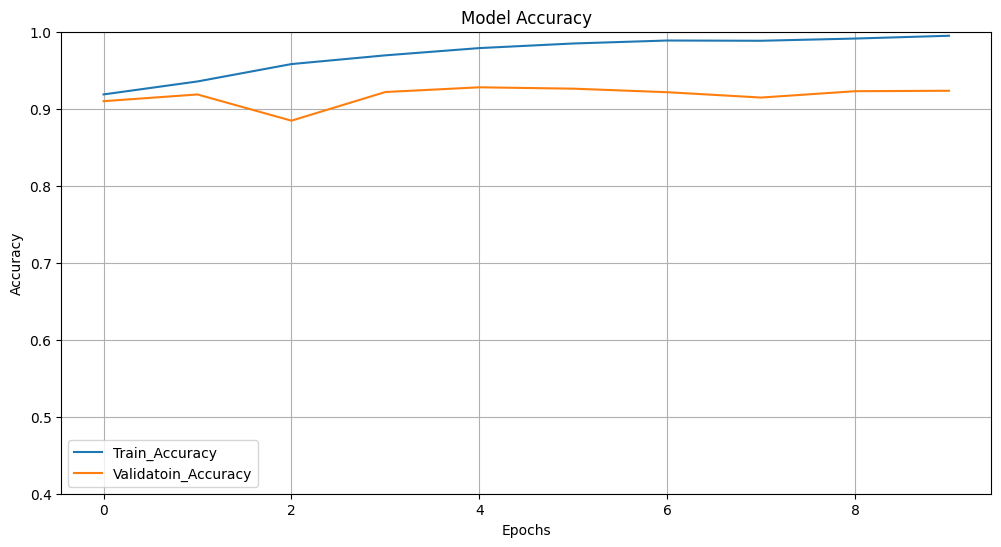

In [15]:
# plotting training and validation accuracy and loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axis(ymin=0.4, ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train_Accuracy', 'Validatoin_Accuracy'])
plt.show()

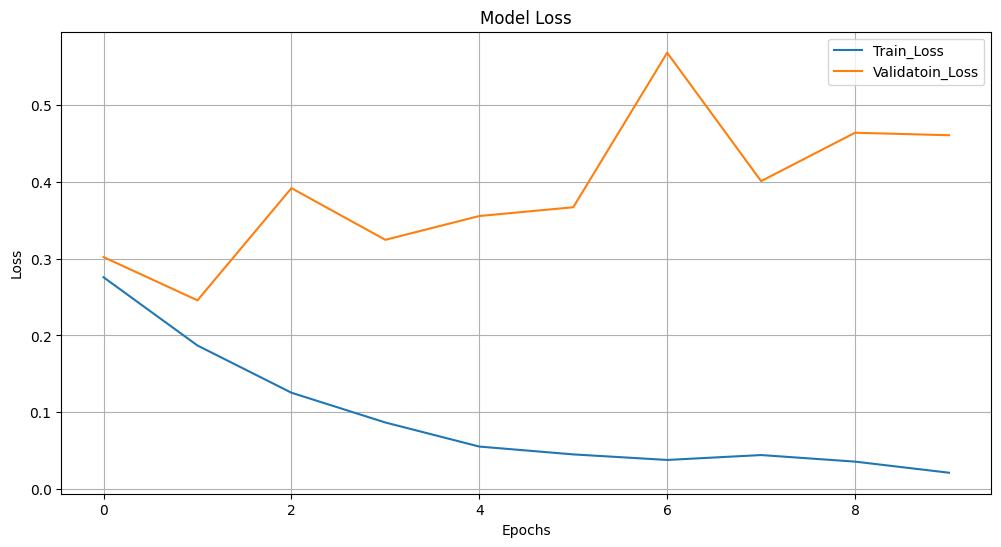

In [14]:
# plotting loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train_Loss', 'Validatoin_Loss'])
plt.show()

In [16]:
# save the model
print("----- <Saving Model> -----")
model.save("miRBind_ResNet.keras")
print("----- <Model Saved> -----\n")